<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/08_1_Ciencia_de_Datos_Semana_08_Inferencia_Cl%C3%A1sica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Taller: Inferencia Clásica y Bayesiana en Series Energéticas

## Parte 1: Planteamiento del Problema

Imaginemos que estamos evaluando el potencial de generación fotovoltaica en una región específica (por ejemplo, Pasto, Nariño). Tenemos un sensor que mide la irradiancia solar ($W/m^2$) todos los días exactamente al mediodía.

Sin embargo, debido a la variabilidad climática (nubosidad aleatoria, aerosoles) y al ruido térmico del propio sensor, nuestras mediciones fluctúan. Asumiremos que la irradiancia al mediodía durante este mes proviene de una distribución Gaussiana con una media $\mu$ (el valor real subyacente que queremos conocer para dimensionar el panel) y una varianza $\sigma^2$ (la incertidumbre/ruido).

**Objetivo:**
Estimar los parámetros desconocidos $\mu$ y $\sigma^2$ a partir de nuestras observaciones limitadas utilizando Inferencia Clásica (Máxima Verosimilitud).

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_33914/1669843626.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax1.axhline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')
/tmp/ipykernel_33914/1669843626.py:34: SyntaxWarning: invalid escape sequence '\m'
  ax2.axvline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')


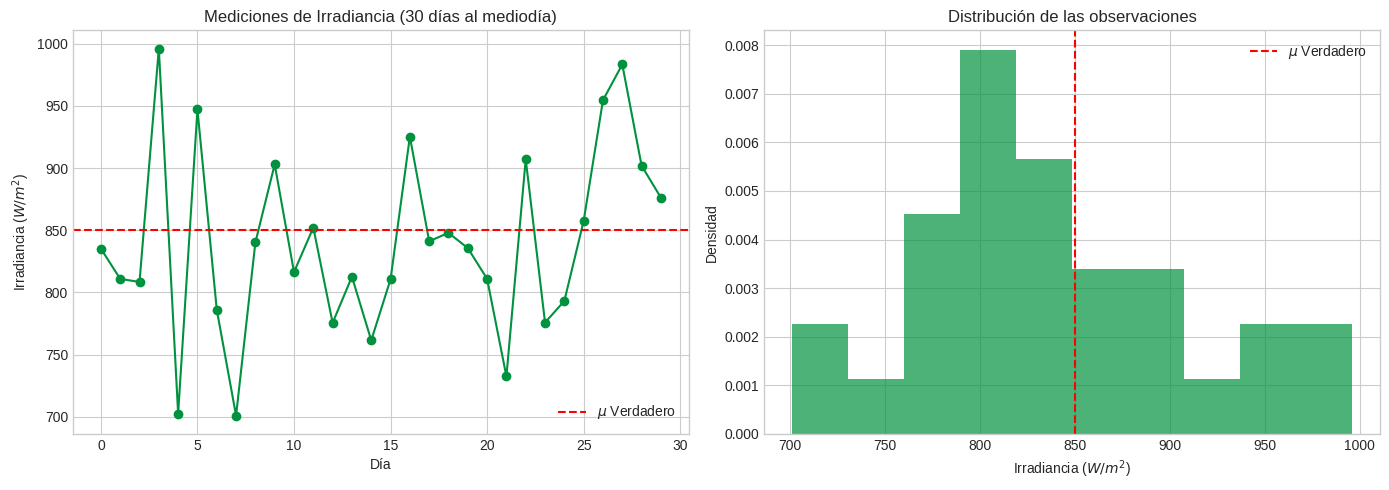

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Configuración estética de las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# 1. GENERACIÓN DE DATOS SINTÉTICOS
#np.random.seed(42) # Para reproducibilidad en clase

# Parámetros "Verdaderos" (Desconocidos para el estimador)
mu_true = 850.0    # Irradiancia media real en W/m^2
sigma_true = 75.0  # Desviación estándar (ruido/clima)

# Simulamos 30 días de mediciones independientes (n=30)
n_samples = 30
mediciones = np.random.normal(loc=mu_true, scale=sigma_true, size=n_samples)

# Visualización de los datos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de serie de tiempo
ax1.plot(mediciones, marker='o', linestyle='-', color='#00923F') # Usando verde Udenar
ax1.axhline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')
ax1.set_title('Mediciones de Irradiancia (30 días al mediodía)')
ax1.set_xlabel('Día')
ax1.set_ylabel('Irradiancia ($W/m^2$)')
ax1.legend()

# Histograma
ax2.hist(mediciones, bins=10, density=True, alpha=0.7, color='#00923F')
ax2.axvline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')
ax2.set_title('Distribución de las observaciones')
ax2.set_xlabel('Irradiancia ($W/m^2$)')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

## Parte 2: Estimación de Máxima Verosimilitud (MLE)

En Inferencia Clásica, los parámetros $\theta = (\mu, \sigma)$ son valores fijos pero desconocidos. El objetivo del estimador de Máxima Verosimilitud (MLE) es encontrar los valores de $\mu$ y $\sigma$ que hacen que los datos observados sean lo más "probables" posible.

Dado un vector de observaciones independientes $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$, la función de verosimilitud conjunta asumiendo ruido Gaussiano es:

$$L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)$$

Para facilitar la optimización, minimizamos el logaritmo negativo de la verosimilitud (Negative Log-Likelihood o NLL):

$$\text{NLL}(\mu, \sigma) = \frac{n}{2}\ln(2\pi) + n\ln(\sigma) + \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

In [ ]:
# 2. DEFINICIÓN DE LA FUNCIÓN DE LOG-VEROSIMILITUD NEGATIVA (NLL)

def negative_log_likelihood(params, data):
    """
    Calcula el NLL asumiendo una distribución Gaussiana.
    params: lista o array con [mu, sigma]
    data: array con las observaciones
    """
    mu, sigma = params

    # Restricción: la desviación estándar no puede ser negativa o cero
    if sigma <= 0:
        return np.inf

    n = len(data)
    # Ecuación del NLL
    term1 = (n / 2) * np.log(2 * np.pi)
    term2 = n * np.log(sigma)
    term3 = np.sum((data - mu)**2) / (2 * sigma**2)

    return term1 + term2 + term3

### 2.1 Optimización Numérica
Vamos a utilizar la librería `scipy.optimize` para encontrar el mínimo de nuestra función NLL, lo cual es equivalente a maximizar la Verosimilitud.

In [ ]:
# Valores iniciales (guesses) para el optimizador
# Empezamos con una suposición aleatoria razonable
initial_guess = [500.0, 10.0]

# Ejecutamos la minimización
resultado_mle = minimize(
    negative_log_likelihood,
    initial_guess,
    args=(mediciones,),
    method='L-BFGS-B',
    bounds=[(None, None), (1e-5, None)] # Sigma debe ser estrictamente positivo
)

mu_mle, sigma_mle = resultado_mle.x

print("--- RESULTADOS DE OPTIMIZACIÓN NUMÉRICA (MLE) ---")
print(f"Mu Verdadero:\t\t {mu_true:.2f}")
print(f"Mu Estimado (MLE):\t {mu_mle:.2f}")
print(f"Sigma Verdadero:\t {sigma_true:.2f}")
print(f"Sigma Estimado (MLE):\t {sigma_mle:.2f}")

--- RESULTADOS DE OPTIMIZACIÓN NUMÉRICA (MLE) ---
Mu Verdadero:		 850.00
Mu Estimado (MLE):	 840.09
Sigma Verdadero:	 75.00
Sigma Estimado (MLE):	 74.18


### 2.2 Comparación Analítica
Como vieron en las clases teóricas (Parte 4b), para una distribución Gaussiana, el proceso de derivar e igualar a cero la función de log-verosimilitud tiene una solución analítica cerrada:

$$\hat{\mu}_{ML} = \frac{1}{n}\sum_{i=1}^{n} x_i = \bar{x}$$
$$\hat{\sigma}^2_{ML} = \frac{1}{n}\sum_{i=1}^{n} (x_i - \bar{x})^2$$

Verifiquemos que el optimizador numérico llegó al mismo resultado que las matemáticas exactas.

In [ ]:
# Cálculo analítico (Media muestral y desviación estándar poblacional sesgada)
mu_analitico = np.mean(mediciones)
sigma_analitico = np.std(mediciones, ddof=0) # ddof=0 para MLE de la varianza

print("--- COMPARACIÓN NUMÉRICO VS ANALÍTICO ---")
print(f"Mu Numérico:\t {mu_mle:.4f} \t| Mu Analítico:\t {mu_analitico:.4f}")
print(f"Sigma Numérico:\t {sigma_mle:.4f} \t| Sigma Analítico: {sigma_analitico:.4f}")

# Comprobación de que son prácticamente idénticos
assert np.isclose(mu_mle, mu_analitico), "Las medias no coinciden"
assert np.isclose(sigma_mle, sigma_analitico), "Las sigmas no coinciden"
print("\n¡Éxito! El optimizador numérico encontró la solución analítica exacta.")

--- COMPARACIÓN NUMÉRICO VS ANALÍTICO ---
Mu Numérico:	 840.0881 	| Mu Analítico:	 840.0878
Sigma Numérico:	 74.1803 	| Sigma Analítico: 74.1798

¡Éxito! El optimizador numérico encontró la solución analítica exacta.


### 2.3 Visualización de la Superficie de Verosimilitud
Para entender por qué el algoritmo de optimización se detuvo en ese punto específico, podemos graficar la superficie bidimensional de la función de Log-Verosimilitud Negativa. El punto más bajo (el valle más profundo) corresponde a nuestro estimador MLE.

<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_33914/4088175587.py:19: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(mu_mle, sigma_mle, 'rx', markersize=12, markeredgewidth=3, label='MLE Estimado ($\hat{\mu}, \hat{\sigma}$)')
/tmp/ipykernel_33914/4088175587.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Media ($\mu$)')
/tmp/ipykernel_33914/4088175587.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Desviación Estándar ($\sigma$)')


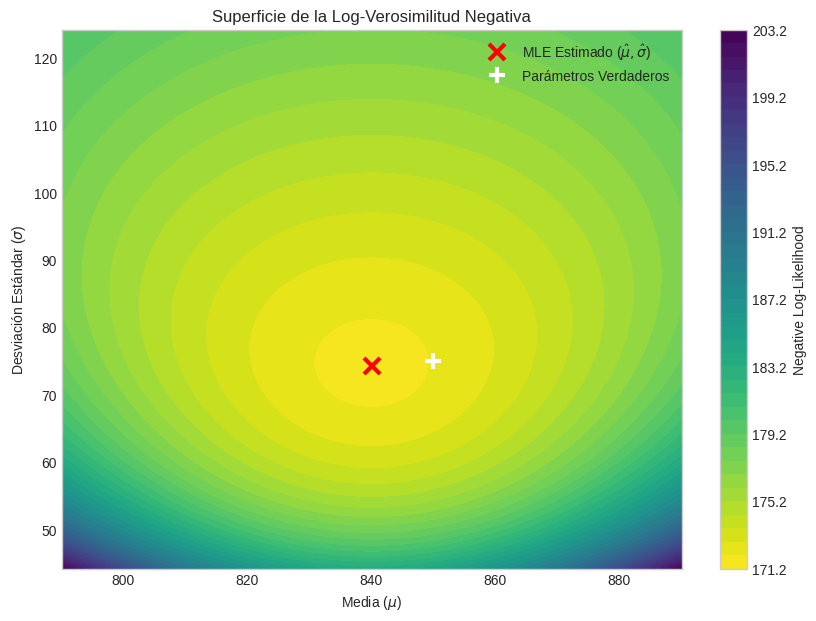

In [ ]:
# Crear una grilla de valores para mu y sigma alrededor de nuestros estimados
mu_vals = np.linspace(mu_mle - 50, mu_mle + 50, 100)
sigma_vals = np.linspace(sigma_mle - 30, sigma_mle + 50, 100)

Mu_grid, Sigma_grid = np.meshgrid(mu_vals, sigma_vals)
NLL_grid = np.zeros_like(Mu_grid)

# Llenar la grilla evaluando la función NLL
for i in range(100):
    for j in range(100):
        NLL_grid[i, j] = negative_log_likelihood([Mu_grid[i, j], Sigma_grid[i, j]], mediciones)

# Graficar contornos
plt.figure(figsize=(10, 7))
cp = plt.contourf(Mu_grid, Sigma_grid, NLL_grid, levels=50, cmap='viridis_r')
plt.colorbar(cp, label='Negative Log-Likelihood')

# Marcar el punto óptimo encontrado
plt.plot(mu_mle, sigma_mle, 'rx', markersize=12, markeredgewidth=3, label='MLE Estimado ($\hat{\mu}, \hat{\sigma}$)')
# Marcar el punto verdadero
plt.plot(mu_true, sigma_true, 'w+', markersize=12, markeredgewidth=3, label='Parámetros Verdaderos')

plt.title('Superficie de la Log-Verosimilitud Negativa')
plt.xlabel('Media ($\mu$)')
plt.ylabel('Desviación Estándar ($\sigma$)')
plt.legend()
plt.show()

# Aplicación a Datos Reales: Inferencia Clásica sobre Rendimientos USD/COP

## Continuación del Taller — Inferencia Clásica y Bayesiana

En esta sección se replica exactamente el mismo flujo de la explicacón profesor, pero reemplazando
los datos sintéticos de irradiancia solar por **rendimientos diarios reales** del tipo
de cambio USD/COP descargados desde Yahoo Finance (2017–2026).

La función `negative_log_likelihood` ya fue definida en las celdas anteriores y se reutiliza directamente.

## Parte A: Descarga y Preprocesamiento de Datos

Se descargan los precios de cierre diarios del USD/COP, se calculan los rendimientos
porcentuales para el manejo de outliers (método IQR), y finalmente se grafican
tanto los **precios** como los **rendimientos de media cero**.

/tmp/ipykernel_33914/1607271460.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dataD = yf.download(ticker, start='2017-01-01', end='2026-03-31')
[*********************100%***********************]  1 of 1 completed


Se identificaron y manejaron 73 outliers en la serie de rendimientos.


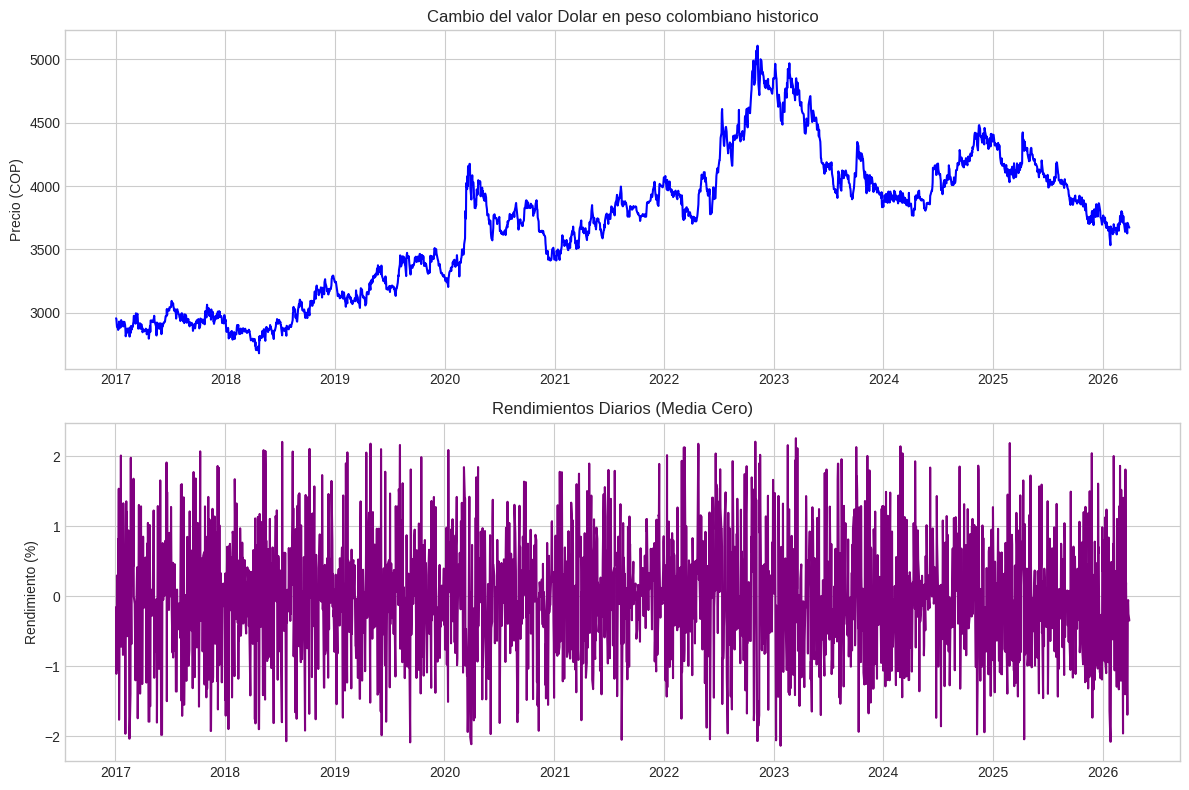

Total de precios disponibles (N): 2405


In [ ]:
import yfinance as yf
import pandas as pd

# Descarga de datos
ticker = 'USDCOP=X'
dataD = yf.download(ticker, start='2017-01-01', end='2026-03-31')
preciosD = dataD['Close'].squeeze()

# Cálculo de rendimientos porcentuales
rendimientosD = preciosD.pct_change().dropna() * 100

# --- Manejo de Outliers en Rendimientos (Reemplazo con valor anterior) ---
Q1 = rendimientosD.quantile(0.25)
Q3 = rendimientosD.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rendimientosD_handled = rendimientosD.copy()
rendimientosD_handled[
    (rendimientosD_handled < lower_bound) |
    (rendimientosD_handled > upper_bound)
] = np.nan

if pd.isna(rendimientosD_handled.iloc[0]):
    rendimientosD_handled.iloc[0] = rendimientosD_handled.bfill().iloc[0]
rendimientosD_filled = rendimientosD_handled.ffill()

num_outliers_identified = rendimientosD.size - rendimientosD_handled.count()
print(f'Se identificaron y manejaron {int(num_outliers_identified)} outliers en la serie de rendimientos.')

rendimientosD = rendimientosD_filled

# Convertir a proceso de media cero
media_rendimientosD = rendimientosD.mean()
rendimientos_mcD = rendimientosD - media_rendimientosD

# Gráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(preciosD, color='blue')
ax1.set_title('Cambio del valor Dolar en peso colombiano historico')
ax1.set_ylabel('Precio (COP)')

ax2.plot(rendimientos_mcD, color='purple')
ax2.set_title('Rendimientos Diarios (Media Cero)')
ax2.set_ylabel('Rendimiento (%)')
plt.tight_layout()
plt.show()

print(f'Total de precios disponibles (N): {len(preciosD)}')

## Parte B: Estimación de Máxima Verosimilitud (MLE) sobre Precios

Al igual que el profesor modeló la irradiancia $x_i \sim \mathcal{N}(\mu, \sigma^2)$,
aquí modelamos directamente los **precios** USD/COP bajo el mismo supuesto:

$$p_i \sim \mathcal{N}(\mu, \sigma^2)$$

El estimador MLE busca los parámetros $(\mu, \sigma)$ que maximizan la verosimilitud
de haber observado los precios registrados, minimizando:

$$\text{NLL}(\mu, \sigma) = \frac{n}{2}\ln(2\pi) + n\ln(\sigma) + \frac{1}{2\sigma^2}\sum_{i=1}^{n}(p_i - \mu)^2$$

### B.1 Optimización Numérica

Usamos `scipy.optimize.minimize` con método `L-BFGS-B`, partiendo de un punto inicial
alejado del óptimo para demostrar la robustez del optimizador.

In [ ]:
# Datos para MLE: precios de cierre USD/COP
precios = preciosD.values   # array numpy de precios en COP
N = len(precios)

# Punto de inicio deliberadamente alejado del óptimo
# (igual que el profesor usó [500.0, 10.0] para irradiancia)
initial_guess = [1000.0, 50.0]   # [mu_0, sigma_0] en COP

resultado_mle = minimize(
    negative_log_likelihood,
    initial_guess,
    args=(precios,),
    method='L-BFGS-B',
    bounds=[(None, None), (1e-5, None)]   # sigma estrictamente positivo
)

mu_mle, sigma_mle = resultado_mle.x

print('--- RESULTADOS DE OPTIMIZACIÓN NUMÉRICA (MLE) ---')
print(f'Punto de inicio      : mu_0 = {initial_guess[0]:.1f} COP, sigma_0 = {initial_guess[1]:.1f} COP')
print(f'Convergió            : {resultado_mle.success}')
print(f'Iteraciones          : {resultado_mle.nit}')
print(f'mu  estimado (MLE)   : {mu_mle:.2f} COP')
print(f'sigma estimado (MLE) : {sigma_mle:.2f} COP')
print(f'NLL mínimo           : {resultado_mle.fun:.4f}')

--- RESULTADOS DE OPTIMIZACIÓN NUMÉRICA (MLE) ---
Punto de inicio      : mu_0 = 1000.0 COP, sigma_0 = 50.0 COP
Convergió            : True
Iteraciones          : 29
mu  estimado (MLE)   : 3697.02 COP
sigma estimado (MLE) : 540.81 COP
NLL mínimo           : 18547.3794


### B.2 Distribución de Precios vs PDF Gaussiana MLE

Superponemos la curva Gaussiana estimada sobre el histograma de precios
para evaluar visualmente la bondad del ajuste.

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_33914/3834051857.py:11: SyntaxWarning: invalid escape sequence '\h'
  label=f'$\hat{{\mu}}$ MLE = {mu_mle:.0f} COP')
/tmp/ipykernel_33914/3834051857.py:11: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\hat{{\mu}}$ MLE = {mu_mle:.0f} COP')
/tmp/ipykernel_33914/3834051857.py:24: SyntaxWarning: invalid escape sequence '\h'
  label=f'$\hat{{\mu}}$ = {mu_mle:.0f} COP')
/tmp/ipykernel_33914/3834051857.py:24: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\hat{{\mu}}$ = {mu_mle:.0f} COP')


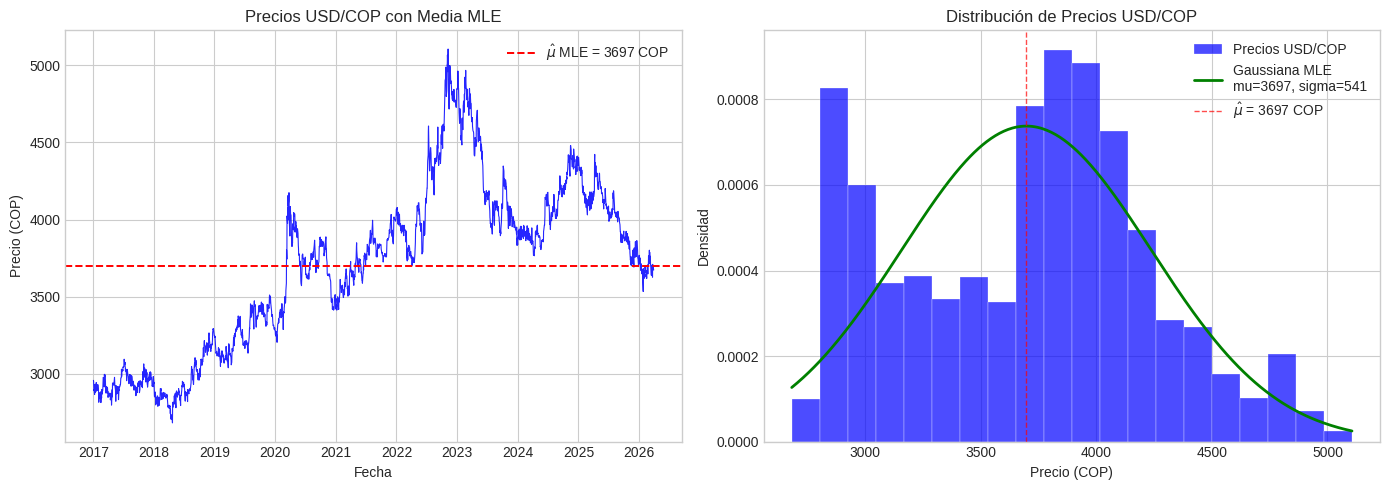

In [ ]:
from scipy.stats import norm

x_range = np.linspace(precios.min(), precios.max(), 400)
pdf_mle  = norm.pdf(x_range, loc=mu_mle, scale=sigma_mle)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Serie de tiempo con media estimada
ax1.plot(preciosD.index, precios, color='blue', linewidth=0.8, alpha=0.85)
ax1.axhline(mu_mle, color='red', linestyle='--', linewidth=1.4,
            label=f'$\hat{{\mu}}$ MLE = {mu_mle:.0f} COP')
ax1.set_title('Precios USD/COP con Media MLE')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (COP)')
ax1.legend()

# Histograma con PDF superpuesta
ax2.hist(precios, bins=20, density=True, alpha=0.7,
         color='blue', edgecolor='white', linewidth=0.3,
         label='Precios USD/COP')
ax2.plot(x_range, pdf_mle, color='green', linewidth=2,
         label=f'Gaussiana MLE\nmu={mu_mle:.0f}, sigma={sigma_mle:.0f}')
ax2.axvline(mu_mle, color='red', linestyle='--', linewidth=1, alpha=0.7,
            label=f'$\hat{{\mu}}$ = {mu_mle:.0f} COP')
ax2.set_title('Distribución de Precios USD/COP')
ax2.set_xlabel('Precio (COP)')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

### B.3 Comparación Analítica

La solución cerrada del MLE Gaussiano aplicada a los precios es:

$$\hat{\mu}_{ML} = \frac{1}{n}\sum_{i=1}^{n} p_i = \bar{p}$$

$$\hat{\sigma}_{ML} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(p_i - \bar{p})^2}$$

> **Nota:** Se usa `ddof=0` (divisor $n$, no $n-1$) porque el MLE de la varianza es el estimador sesgado.

In [ ]:
# Solución analítica cerrada
mu_analitico    = np.mean(precios)
sigma_analitico = np.std(precios, ddof=0)   # MLE → divisor n

print('--- COMPARACIÓN NUMÉRICO VS ANALÍTICO ---')
print(f'mu  numérico  : {mu_mle:.4f} COP  |  mu  analítico  : {mu_analitico:.4f} COP')
print(f'sigma numérico: {sigma_mle:.4f} COP  |  sigma analítico: {sigma_analitico:.4f} COP')

assert np.isclose(mu_mle,    mu_analitico,    atol=1e-2), 'Las medias no coinciden'
assert np.isclose(sigma_mle, sigma_analitico, atol=1e-2), 'Las sigmas no coinciden'
print('\n¡Éxito! El optimizador numérico encontró la solución analítica exacta.')

--- COMPARACIÓN NUMÉRICO VS ANALÍTICO ---
mu  numérico  : 3697.0207 COP  |  mu  analítico  : 3697.0141 COP
sigma numérico: 540.8087 COP  |  sigma analítico: 540.8108 COP

¡Éxito! El optimizador numérico encontró la solución analítica exacta.


### B.4 Superficie de la Log-Verosimilitud Negativa

Graficamos el contorno 2D del NLL en una grilla centrada en los estimadores MLE.
La estructura es idéntica a la del profesor — el valle más profundo corresponde
al punto óptimo $(\hat{\mu}, \hat{\sigma})$.

<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_33914/1085088106.py:24: SyntaxWarning: invalid escape sequence '\h'
  label=f'MLE Estimado ($\hat{{\mu}}$={mu_mle:.0f}, $\hat{{\sigma}}$={sigma_mle:.0f})')
/tmp/ipykernel_33914/1085088106.py:24: SyntaxWarning: invalid escape sequence '\m'
  label=f'MLE Estimado ($\hat{{\mu}}$={mu_mle:.0f}, $\hat{{\sigma}}$={sigma_mle:.0f})')
/tmp/ipykernel_33914/1085088106.py:24: SyntaxWarning: invalid escape sequence '\h'
  label=f'MLE Estimado ($\hat{{\mu}}$={mu_mle:.0f}, $\hat{{\sigma}}$={sigma_mle:.0f})')
/tmp/ipykernel_33914/1085088106.py:24: SyntaxWarning: invalid escape sequence '

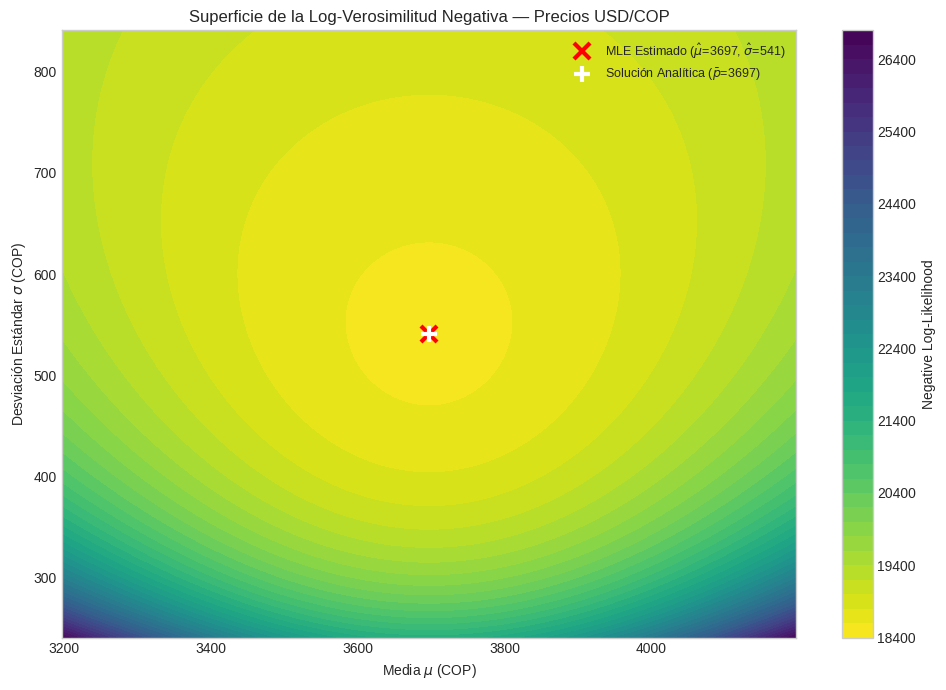

In [ ]:
# Grilla centrada en los estimadores MLE (misma lógica del profesor)
delta_mu    = 500    # ventana ± alrededor de mu_mle en COP
delta_sigma = 300    # ventana ± alrededor de sigma_mle en COP

mu_vals    = np.linspace(mu_mle    - delta_mu,    mu_mle    + delta_mu,    100)
sigma_vals = np.linspace(max(sigma_mle - delta_sigma, 1.0),
                         sigma_mle + delta_sigma, 100)

Mu_grid, Sigma_grid = np.meshgrid(mu_vals, sigma_vals)
NLL_grid = np.zeros_like(Mu_grid)

for i in range(100):
    for j in range(100):
        NLL_grid[i, j] = negative_log_likelihood(
            [Mu_grid[i, j], Sigma_grid[i, j]], precios
        )

plt.figure(figsize=(10, 7))
cp = plt.contourf(Mu_grid, Sigma_grid, NLL_grid, levels=50, cmap='viridis_r')
plt.colorbar(cp, label='Negative Log-Likelihood')

plt.plot(mu_mle, sigma_mle,
         'rx', markersize=12, markeredgewidth=3,
         label=f'MLE Estimado ($\hat{{\mu}}$={mu_mle:.0f}, $\hat{{\sigma}}$={sigma_mle:.0f})')
plt.plot(mu_analitico, sigma_analitico,
         'w+', markersize=12, markeredgewidth=3,
         label=f'Solución Analítica ($\\bar{{p}}$={mu_analitico:.0f})')

plt.title('Superficie de la Log-Verosimilitud Negativa — Precios USD/COP')
plt.xlabel('Media $\\mu$ (COP)')
plt.ylabel('Desviación Estándar $\\sigma$ (COP)')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Resumen de Resultados

| Parámetro | MLE Numérico | MLE Analítico | Interpretación |
|-----------|:-----------:|:-------------:|----------------|
| $\hat{\mu}$ (COP) | `mu_mle` | `mu_analitico` | Precio medio histórico estimado del USD/COP |
| $\hat{\sigma}$ (COP) | `sigma_mle` | `sigma_analitico` | Dispersión/volatilidad histórica de los precios |

**Conclusiones:**
- El optimizador `L-BFGS-B` convergió a la solución analítica exacta, confirmando
  la correcta implementación de la NLL.
- $\hat{\mu}$ representa el precio promedio del dólar en pesos colombianos en el período.
- $\hat{\sigma}$ captura la **volatilidad estructural** del tipo de cambio,
  reflejo de la incertidumbre macroeconómica colombiana en el período 2017–2026.